# Load ETAS vs thinning ensemble realizations

Load forecast catalogs produced by `runnable_code/catalog_california_etas_vs_thinning_ensemble.py`.

Each realization lives under `<ensemble_dir>/seed_<seed>/` with:
- `etas_catalog.csv`
- `thinning_catalog.csv`
- `summary.csv`

Legacy layouts (`realizations/seed_<seed>/` or `inv_*_seed<start>/` folders) are also discovered when loading.

Set **`ENSEMBLE_DIR`** below, then choose how many realizations to load:
- **`all`** (default) — every `seed_*` folder
- **`first_n`** — the first *n* seeds in sorted order
- **`seeds`** — an explicit list of integer seeds

If `per_realization_metrics.csv` is not yet written (ensemble still running), Tier 1 metrics are **computed in memory** from the loaded catalogs.

In [51]:
%matplotlib inline

from __future__ import annotations

import importlib.util
import json
import sys
from pathlib import Path
from typing import Literal

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown
from scipy import stats
from shapely.geometry import Polygon

ETAS_COLOR = "seagreen"
THINNING_COLOR = "indianred"


2026-06-26 19:44:45,886 - DEBUG - Loaded backend inline version unknown.


In [52]:
def find_repo_root() -> Path:
    """Locate etas repo root even if the kernel cwd is not the repo."""
    for start in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (start / "runnable_code" / "catalog_california_etas_vs_thinning_ensemble.py").is_file():
            return start
        if start.name == "notebooks" and (start.parent / "runnable_code").is_dir():
            return start.parent
    raise FileNotFoundError(
        "Could not find etas repo root. Open this notebook from the etas checkout "
        "and/or set the kernel cwd to the repo or notebooks/ folder."
    )


REPO_ROOT = find_repo_root()
ENSEMBLES_ROOT = REPO_ROOT / "outputs/catalog_etas_vs_thinning/ensembles"

# Explicit ensemble folder, or None = auto-pick newest inv_* dir that has seed_* data
ENSEMBLE_DIR: Path | None = ENSEMBLES_ROOT / "inv_c0b4eb6d6e4a24f1"

# --- which realizations to load ---
LOAD_MODE: Literal["all", "first_n", "seeds"] = "all"
FIRST_N: int = 5          # used when LOAD_MODE == "first_n"
SEEDS: list[int] = [100]  # used when LOAD_MODE == "seeds"


In [53]:
def list_ensemble_dirs(ensembles_root: Path) -> list[Path]:
    """``inv_*`` folders under ``ensembles_root`` that contain at least one seed."""
    if not ensembles_root.is_dir():
        return []
    found: list[Path] = []
    for path in ensembles_root.iterdir():
        if not path.is_dir() or not path.name.startswith("inv_"):
            continue
        try:
            discover_realization_seeds(path)
        except FileNotFoundError:
            continue
        found.append(path)
    return sorted(found, key=lambda p: p.stat().st_mtime, reverse=True)


def resolve_ensemble_dir(explicit: Path | None, ensembles_root: Path) -> Path:
    if explicit is not None:
        path = explicit.expanduser()
        if not path.is_absolute():
            path = (REPO_ROOT / path).resolve()
        else:
            path = path.resolve()
        if path.is_dir():
            return path

    candidates = list_ensemble_dirs(ensembles_root)
    lines = "\n".join(f"  - {p}" for p in candidates) if candidates else "  (none)"
    if explicit is not None:
        raise FileNotFoundError(
            f"Ensemble directory not found: {explicit}\n"
            f"REPO_ROOT={REPO_ROOT}\n"
            f"ENSEMBLES_ROOT exists={ensembles_root.is_dir()}\n"
            f"Available ensemble dirs with seed_* data:\n{lines}"
        )
    if not candidates:
        raise FileNotFoundError(
            f"No ensemble output under {ensembles_root.resolve()}.\n"
            "Run runnable_code/catalog_california_etas_vs_thinning_ensemble.py first."
        )
    chosen = candidates[0]
    print(f"Auto-selected ensemble dir: {chosen}")
    return chosen


def discover_realization_seeds(ensemble_dir: Path) -> list[int]:
    """Sorted seeds from ``seed_<seed>/`` (flat or legacy ``realizations/`` layout)."""
    seeds: set[int] = set()
    if not ensemble_dir.is_dir():
        raise FileNotFoundError(f"Not a directory: {ensemble_dir}")

    for path in ensemble_dir.iterdir():
        if path.is_dir() and path.name.startswith("seed_"):
            seeds.add(int(path.name.removeprefix("seed_")))

    legacy = ensemble_dir / "realizations"
    if legacy.is_dir():
        for path in legacy.iterdir():
            if path.is_dir() and path.name.startswith("seed_"):
                seeds.add(int(path.name.removeprefix("seed_")))

    if not seeds:
        raise FileNotFoundError(
            f"No seed_* folders under {ensemble_dir} (or {legacy})"
        )
    return sorted(seeds)


def select_seeds(
    available: list[int],
    *,
    mode: Literal["all", "first_n", "seeds"],
    first_n: int | None = None,
    seeds: list[int] | None = None,
) -> list[int]:
    if mode == "all":
        return list(available)
    if mode == "first_n":
        if first_n is None or first_n < 1:
            raise ValueError("first_n must be >= 1 when LOAD_MODE is 'first_n'")
        return available[:first_n]
    if mode == "seeds":
        if not seeds:
            raise ValueError("SEEDS must be non-empty when LOAD_MODE is 'seeds'")
        missing = sorted(set(seeds) - set(available))
        if missing:
            raise ValueError(f"Requested seeds not found: {missing}; available: {available}")
        return [s for s in available if s in set(seeds)]
    raise ValueError(f"Unknown mode: {mode!r}")


def _realization_dir_for_seed(ensemble_dir: Path, seed: int) -> Path:
    flat = ensemble_dir / f"seed_{seed}"
    legacy = ensemble_dir / "realizations" / f"seed_{seed}"
    if flat.is_dir():
        return flat
    if legacy.is_dir():
        return legacy
    return flat


def load_realization_catalogs(ensemble_dir: Path, seed: int) -> dict[str, pd.DataFrame]:
    run_dir = _realization_dir_for_seed(ensemble_dir, seed)
    etas_path = run_dir / "etas_catalog.csv"
    thin_path = run_dir / "thinning_catalog.csv"
    for path in (etas_path, thin_path):
        if not path.is_file():
            raise FileNotFoundError(path)
    etas = pd.read_csv(etas_path)
    thinning = pd.read_csv(thin_path)
    for df in (etas, thinning):
        if "dt_days" in df.columns:
            df["dt_days"] = pd.to_numeric(df["dt_days"], errors="coerce")
        if "m" in df.columns:
            df["m"] = pd.to_numeric(df["m"], errors="coerce")
    return {"etas": etas, "thinning": thinning}


def load_ensemble_realizations(
    ensemble_dir: Path,
    *,
    mode: Literal["all", "first_n", "seeds"] = "all",
    first_n: int | None = None,
    seeds: list[int] | None = None,
) -> tuple[dict[int, dict[str, pd.DataFrame]], pd.DataFrame, dict]:
    """Return (catalogs_by_seed, metrics_df, meta)."""
    ensemble_dir = ensemble_dir.resolve()
    available = discover_realization_seeds(ensemble_dir)
    selected = select_seeds(available, mode=mode, first_n=first_n, seeds=seeds)

    meta_path = ensemble_dir / "ensemble_meta.json"
    meta = json.loads(meta_path.read_text(encoding="utf-8")) if meta_path.is_file() else {}

    metrics_path = ensemble_dir / "per_realization_metrics.csv"
    metrics_df = pd.read_csv(metrics_path) if metrics_path.is_file() else pd.DataFrame()
    if not metrics_df.empty and "seed" in metrics_df.columns:
        metrics_df = metrics_df[metrics_df["seed"].isin(selected)].reset_index(drop=True)

    catalogs_by_seed: dict[int, dict[str, pd.DataFrame]] = {}
    for seed in selected:
        catalogs_by_seed[seed] = load_realization_catalogs(ensemble_dir, seed)

    return catalogs_by_seed, metrics_df, meta


_METRIC_COLUMNS = [
    "seed",
    "etas_n_events",
    "thinning_n_events",
    "etas_background",
    "thinning_background",
    "etas_triggered",
    "thinning_triggered",
    "etas_median_dt_days",
    "thinning_median_dt_days",
    "etas_max_magnitude",
    "thinning_max_magnitude",
    "thinning_over_etas_ratio",
]


def realization_metrics_row(
    seed: int,
    etas_catalog: pd.DataFrame,
    thinning_catalog: pd.DataFrame,
) -> dict:
    etas_n = len(etas_catalog)
    thin_n = len(thinning_catalog)
    etas_bg = (
        int((etas_catalog.get("event_source") == "background").sum())
        if "event_source" in etas_catalog.columns
        else np.nan
    )
    thin_bg = int((thinning_catalog["event_source"] == "background").sum())
    etas_trig = (
        int((etas_catalog.get("event_source") == "triggered").sum())
        if "event_source" in etas_catalog.columns
        else np.nan
    )
    thin_trig = int((thinning_catalog["event_source"] == "triggered").sum())
    return {
        "seed": seed,
        "etas_n_events": etas_n,
        "thinning_n_events": thin_n,
        "etas_background": etas_bg,
        "thinning_background": thin_bg,
        "etas_triggered": etas_trig,
        "thinning_triggered": thin_trig,
        "etas_median_dt_days": float(np.median(etas_catalog["dt_days"])) if etas_n else np.nan,
        "thinning_median_dt_days": float(np.median(thinning_catalog["dt_days"]))
        if thin_n
        else np.nan,
        "etas_max_magnitude": float(etas_catalog["m"].max()) if etas_n else np.nan,
        "thinning_max_magnitude": float(thinning_catalog["m"].max()) if thin_n else np.nan,
        "thinning_over_etas_ratio": thin_n / etas_n if etas_n else np.nan,
    }


def compute_metrics_df(
    catalogs_by_seed: dict[int, dict[str, pd.DataFrame]],
    selected_seeds: list[int],
) -> pd.DataFrame:
    rows = [
        realization_metrics_row(seed, catalogs_by_seed[seed]["etas"], catalogs_by_seed[seed]["thinning"])
        for seed in selected_seeds
    ]
    return pd.DataFrame(rows, columns=_METRIC_COLUMNS)


def ensure_metrics_df(
    metrics_df: pd.DataFrame,
    catalogs_by_seed: dict[int, dict[str, pd.DataFrame]],
    selected_seeds: list[int],
) -> pd.DataFrame:
    """Use on-disk metrics when present; otherwise compute and keep in notebook memory."""
    if not metrics_df.empty:
        return metrics_df
    print("per_realization_metrics.csv missing — computing metrics from loaded catalogs.")
    return compute_metrics_df(catalogs_by_seed, selected_seeds)


def cumulative_on_grid(dt_days: np.ndarray, t_grid: np.ndarray) -> np.ndarray:
    """Step-function cumulative count N(t) on a uniform day grid."""
    dt_days = dt_days[np.isfinite(dt_days)]
    if dt_days.size == 0:
        return np.zeros_like(t_grid, dtype=float)
    return np.searchsorted(np.sort(dt_days), t_grid, side="right").astype(float)


def events_per_time_bin(dt_days: np.ndarray, bin_edges: np.ndarray) -> np.ndarray:
    """Histogram of event counts per time bin (not cumulative)."""
    dt_days = dt_days[np.isfinite(dt_days)]
    if dt_days.size == 0:
        return np.zeros(len(bin_edges) - 1, dtype=float)
    counts, _ = np.histogram(dt_days, bins=bin_edges)
    return counts.astype(float)


def interevent_times(dt_days: np.ndarray) -> np.ndarray:
    dt_days = np.sort(dt_days[np.isfinite(dt_days)])
    if dt_days.size < 2:
        return np.array([], dtype=float)
    return np.diff(dt_days)


def nearest_neighbor_distances_km(cat: pd.DataFrame) -> np.ndarray:
    import etas.utility_functions as utility_functions

    y = cat["y"].to_numpy(dtype=float)
    x = cat["x"].to_numpy(dtype=float)
    n = len(y)
    if n < 2:
        return np.array([], dtype=float)
    dists = np.empty(n, dtype=float)
    for i in range(n):
        d2 = utility_functions.spatial_distance_squared_km2(y, x, y[i], x[i])
        d2[i] = np.inf
        dists[i] = np.sqrt(np.min(d2))
    return dists


def etas_parent_distances_km(cat: pd.DataFrame) -> np.ndarray:
    import etas.utility_functions as utility_functions

    if "parent_latitude" not in cat.columns or "parent_longitude" not in cat.columns:
        return np.array([], dtype=float)
    if "event_source" in cat.columns:
        triggered = cat[cat["event_source"] == "triggered"]
    elif "is_background" in cat.columns:
        triggered = cat[~cat["is_background"].astype(bool)]
    else:
        triggered = cat
    if triggered.empty:
        return np.array([], dtype=float)
    dists = [
        float(np.sqrt(utility_functions.spatial_distance_squared_km2(
            row["y"], row["x"], row["parent_latitude"], row["parent_longitude"]
        )))
        for _, row in triggered.iterrows()
    ]
    return np.asarray(dists, dtype=float)


_continuation_module = None


def load_continuation_module():
    global _continuation_module
    if _continuation_module is not None:
        return _continuation_module
    path = REPO_ROOT / "runnable_code/catalog_california_etas_vs_thinning_continuation.py"
    spec = importlib.util.spec_from_file_location("catalog_california_etas_vs_thinning_continuation", path)
    if spec is None or spec.loader is None:
        raise ImportError(f"Could not load continuation module from {path}")
    mod = importlib.util.module_from_spec(spec)
    sys.modules[spec.name] = mod
    spec.loader.exec_module(mod)
    _continuation_module = mod
    return mod


def load_intensity_context(
    ensemble_dir: Path,
    meta: dict,
    seed: int,
) -> dict:
    """Polygon, ETAS parameters, and history for λ(t) / parent-distance helpers."""
    from etas.inversion import ETASParameterCalculation

    cat_cmp = load_continuation_module()
    realization_meta_path = _realization_dir_for_seed(ensemble_dir, seed) / "realization_meta.json"
    rmeta = (
        json.loads(realization_meta_path.read_text(encoding="utf-8"))
        if realization_meta_path.is_file()
        else {}
    )
    inv_id = meta.get("inversion_id") or rmeta.get("inversion_id")
    if not inv_id:
        raise ValueError("Could not determine inversion_id from meta or realization_meta.json")
    a_h_resolution = int(meta.get("a_h_resolution") or rmeta.get("a_h_resolution", 500))

    inv_dir = REPO_ROOT / "outputs/catalog_etas_vs_thinning/inversions" / f"inv_{inv_id}"
    params_json = inv_dir / f"parameters_{inv_id}.json"
    if not params_json.is_file():
        raise FileNotFoundError(f"Inversion parameters not found: {params_json}")

    inversion_output = json.loads(params_json.read_text(encoding="utf-8"))
    etas_inversion = ETASParameterCalculation.load_calculation(inversion_output)
    theta_0 = cat_cmp.expand_theta_log10(dict(etas_inversion.theta))
    mc = float(etas_inversion.m_ref - etas_inversion.delta_m / 2)
    theta_0["m_c"] = mc
    polygon = Polygon(etas_inversion.shape_coords)

    source_events = etas_inversion.source_events.copy()
    if "xi_plus_1" not in source_events.columns:
        source_events["xi_plus_1"] = 1.0
    auxiliary_catalog = pd.merge(
        source_events,
        etas_inversion.catalog[["latitude", "longitude", "time", "magnitude"]],
        left_index=True,
        right_index=True,
        how="left",
    )
    timewindow_end = meta.get("timewindow_end") or rmeta.get("timewindow_end")
    testwindow_end = meta.get("testwindow_end") or rmeta.get("testwindow_end")
    forecast_start_dt = pd.to_datetime(timewindow_end, utc=True).tz_convert(None)
    forecast_end_dt = pd.to_datetime(testwindow_end, utc=True).tz_convert(None)

    history_df = auxiliary_catalog.loc[auxiliary_catalog["time"] <= forecast_start_dt].copy()
    history_df = history_df.sort_values("time").reset_index(drop=True)
    history_df["t"] = (history_df["time"] - pd.Timestamp("1970-01-01")) / pd.Timedelta("1D")
    history_df["x"] = history_df["longitude"].astype(float)
    history_df["y"] = history_df["latitude"].astype(float)
    history_df["m"] = history_df["magnitude"].astype(float)

    forecast_start_t = float(history_df["t"].max()) if len(history_df) else (
        (forecast_start_dt - pd.Timestamp("1970-01-01")) / pd.Timedelta("1D")
    )
    forecast_end_t = (forecast_end_dt - pd.Timestamp("1970-01-01")) / pd.Timedelta("1D")
    hist_events = [cat_cmp.to_history_dict(row) for _, row in history_df.iterrows()]

    return {
        "module": cat_cmp,
        "polygon": polygon,
        "theta_0": theta_0,
        "mc": mc,
        "beta_main": float(etas_inversion.beta),
        "a_h_resolution": a_h_resolution,
        "history_df": history_df,
        "hist_events": hist_events,
        "forecast_start_t": forecast_start_t,
        "forecast_end_t": forecast_end_t,
        "forecast_days": forecast_end_t - forecast_start_t,
    }


def thinning_dominant_parent_distances_km(cat: pd.DataFrame, ctx: dict) -> np.ndarray:
    """Distance to the dominant triggering parent at each event time (thinning logic)."""
    import etas.utility_functions as utility_functions

    cat_cmp = ctx["module"]
    poly = ctx["polygon"]
    params = ctx["theta_0"]
    resolution = ctx["a_h_resolution"]
    events = list(ctx["hist_events"])

    triggered = cat[cat["event_source"] == "triggered"] if "event_source" in cat.columns else cat
    dists: list[float] = []
    for _, row in triggered.iterrows():
        t = float(row["t"])
        contribs = [
            cat_cmp.A_h(poly, h, params, resolution) * cat_cmp.g(t, h, params)
            for h in events
            if h["t"] < t
        ]
        if not contribs:
            continue
        parent = events[int(np.argmax(contribs))]
        d2 = utility_functions.spatial_distance_squared_km2(
            float(row["y"]), float(row["x"]), parent["y"], parent["x"]
        )
        dists.append(float(np.sqrt(d2)))
        events.append(
            {"m": float(row["m"]), "x": float(row["x"]), "y": float(row["y"]), "t": t}
        )
    return np.asarray(dists, dtype=float)


def lambda_on_grid(cat: pd.DataFrame, ctx: dict, t_grid: np.ndarray) -> np.ndarray:
    cat_cmp = ctx["module"]
    evs = cat_cmp._events_from_catalog(cat, ctx["hist_events"])
    return np.array([
        cat_cmp.lambda_s_total(t, evs, ctx["polygon"], ctx["theta_0"], ctx["a_h_resolution"])
        for t in t_grid
    ])


def integrated_lambda(lam: np.ndarray, t_grid: np.ndarray) -> float:
    return float(np.trapz(lam, t_grid))


def l2_curve_distance(curve_a: np.ndarray, curve_b: np.ndarray, t_grid: np.ndarray) -> float:
    diff = curve_a - curve_b
    return float(np.sqrt(np.trapz(diff * diff, t_grid)))


In [54]:
ensemble_dir = resolve_ensemble_dir(ENSEMBLE_DIR, ENSEMBLES_ROOT)

available_seeds = discover_realization_seeds(ensemble_dir)
selected_seeds = select_seeds(
    available_seeds,
    mode=LOAD_MODE,
    first_n=FIRST_N,
    seeds=SEEDS,
)

catalogs_by_seed, metrics_df, meta = load_ensemble_realizations(
    ensemble_dir,
    mode=LOAD_MODE,
    first_n=FIRST_N,
    seeds=SEEDS,
)
metrics_df = ensure_metrics_df(metrics_df, catalogs_by_seed, selected_seeds)

display(Markdown(f"**REPO_ROOT:** `{REPO_ROOT}`"))
display(Markdown(f"**Ensemble dir:** `{ensemble_dir}`"))
display(Markdown(f"**Available seeds:** {available_seeds}"))
display(Markdown(f"**Loaded seeds ({LOAD_MODE}):** {selected_seeds}"))
if meta:
    display(Markdown(
        f"Forecast window: `{meta.get('timewindow_end')}` → `{meta.get('testwindow_end')}` "
        f"({meta.get('forecast_days', '?')} days)"
    ))

metrics_df


per_realization_metrics.csv missing — computing metrics from loaded catalogs.


**REPO_ROOT:** `/home/neriberman/Repos/etas`

**Ensemble dir:** `/home/neriberman/Repos/etas/outputs/catalog_etas_vs_thinning/ensembles/inv_c0b4eb6d6e4a24f1`

**Available seeds:** [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62]

**Loaded seeds (all):** [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62]

,seed,etas_n_events,thinning_n_events,etas_background,thinning_background,etas_triggered,thinning_triggered,etas_median_dt_days,thinning_median_dt_days,etas_max_magnitude,thinning_max_magnitude,thinning_over_etas_ratio
0,0,1453,2127,231,223,1222,1904,2477.095903,2550.238429,7.270355,8.229553,1.463868
1,1,1491,1156,225,238,1266,918,2952.971184,2301.704275,6.829795,6.457294,0.775319
2,2,1445,1254,226,247,1219,1007,2674.968949,2335.381538,6.710289,6.458501,0.867820
3,3,1215,1394,231,227,984,1167,2655.772054,2500.158963,6.262460,6.651272,1.147325
4,4,1167,1420,238,226,929,1194,2807.328342,2381.406609,7.150089,6.822966,1.216795
...,...,...,...,...,...,...,...,...,...,...,...,...
58,58,1203,1219,223,259,980,960,2427.745213,2155.701666,6.397693,6.672329,1.013300
59,59,1351,1078,256,207,1095,871,2948.378784,2887.012632,6.871199,6.454972,0.797927
60,60,1422,1580,220,241,1202,1339,2634.107501,2286.669972,7.098236,7.116100,1.111111
61,61,1445,1126,245,247,1200,879,2745.189316,2468.443093,7.123067,5.965610,0.779239


In [55]:
# Convenience views for interactive analysis
etas_by_seed = {seed: catalogs["etas"] for seed, catalogs in catalogs_by_seed.items()}
thinning_by_seed = {seed: catalogs["thinning"] for seed, catalogs in catalogs_by_seed.items()}

# Example: peek at one realization
example_seed = selected_seeds[0]
print(f"ETAS catalog (seed={example_seed}), n={len(etas_by_seed[example_seed])}")
display(etas_by_seed[example_seed].head())
print(f"Thinning catalog (seed={example_seed}), n={len(thinning_by_seed[example_seed])}")
display(thinning_by_seed[example_seed].head())


ETAS catalog (seed=0), n=1453


,G,angle,degree_lat,degree_lon,evt_id,expected_n_aftershocks,gen_0_parent,generation,is_background,l_hat,...,source_to_end_time_distance,time,time_delta,xi_plus_1,t,dt_days,x,y,m,event_source
0,NaN,0.480341,111.318845,90.280310,NaN,1.222251,3295,1,False,NaN,...,NaN,2007-01-01 19:27:00.111997607,11.504917,1.0,13514.810418,0.842001,-115.067507,35.836085,4.506801,triggered
1,NaN,0.821762,111.318845,90.245266,NaN,0.716669,3295,2,False,NaN,...,NaN,2007-01-03 07:36:27.843009724,1.506571,1.0,13516.316989,2.348572,-115.052466,35.847422,4.012160,triggered
2,NaN,5.203896,111.318845,90.232368,NaN,0.888580,3295,3,False,NaN,...,NaN,2007-01-03 21:31:15.863140930,0.579722,1.0,13516.896711,2.928294,-115.078384,35.858669,4.211385,triggered
3,NaN,NaN,NaN,NaN,3305.0,0.512853,1,0,True,NaN,...,NaN,2007-01-04 09:31:24.718394000,NaN,1.0,13517.396814,3.428396,-120.936228,34.174271,3.702104,background
4,NaN,3.172926,111.318845,91.139800,NaN,0.480248,3293,1,False,NaN,...,NaN,2007-01-05 05:52:38.999385465,15.060070,1.0,13518.244896,4.276478,-118.294272,35.039750,3.641241,triggered


Thinning catalog (seed=0), n=2127


,t,x,y,m,event_source,dt_days
0,13515.833702,-115.381527,35.808598,3.761060,triggered,1.865285
1,13516.874540,-117.105629,33.451777,4.440460,triggered,2.906122
2,13517.558170,-118.482190,34.679199,3.783738,triggered,3.589753
3,13517.755393,-117.114086,33.470902,4.049776,triggered,3.786976
4,13518.013275,-117.092267,33.475529,3.610240,triggered,4.044858


## ETAS vs thinning comparison

**Tier 1 — scalar summaries:** event counts, ratio, background/triggered fractions, median timing, max magnitude, cumulative N(t), and events per time bin.

**Tier 2 — distributional:** interevent times, nearest-neighbor distances, distance to triggering parent.

**Tier 3 — mechanistic:** conditional intensity λ(t) and integrated-rate consistency.

**Formal tests:** paired Wilcoxon on counts, KS on timing/magnitude, permutation test on mean count difference; N(t) mean-curve difference and per-seed L2 distance.

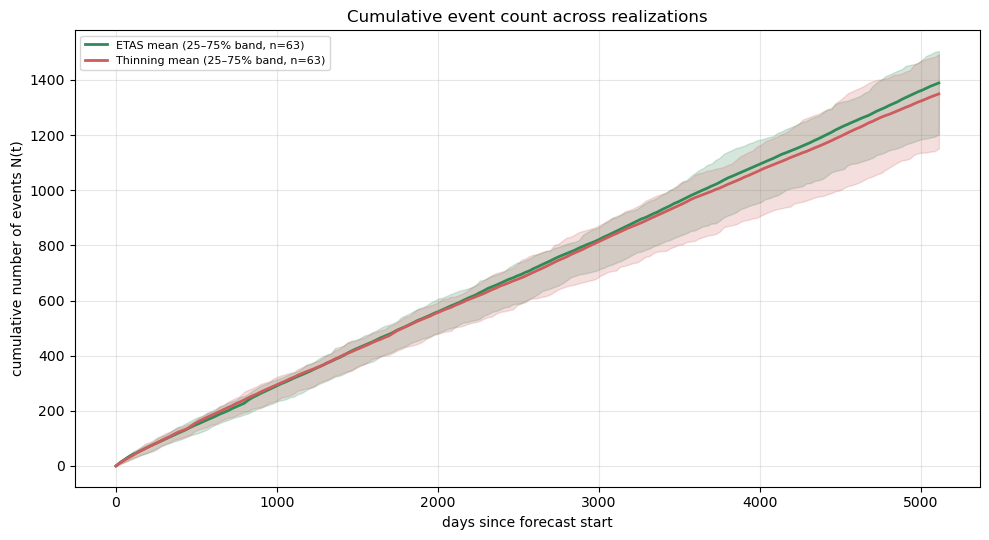

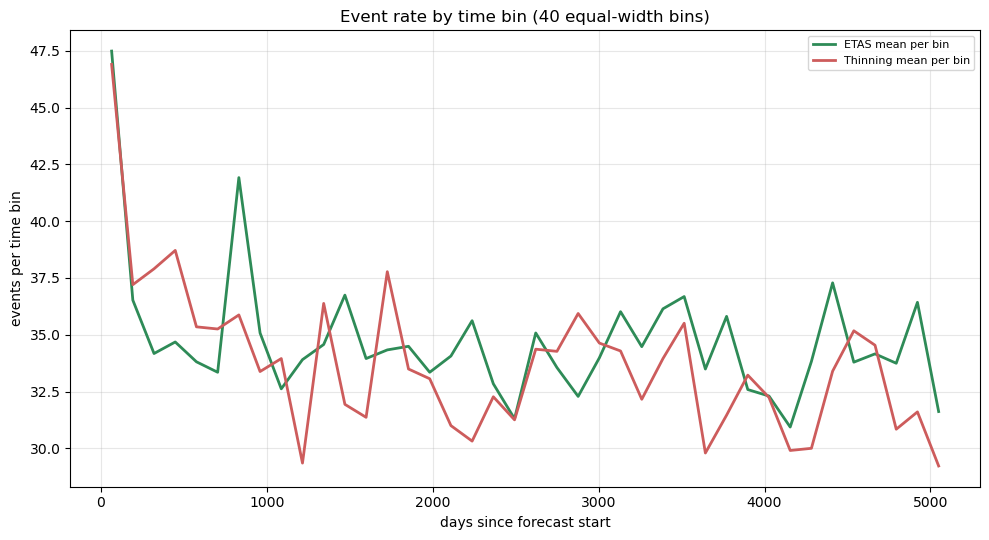

**N(t) curve agreement (across loaded seeds):**

,metric,value
0,max |mean ETAS − mean thinning| on t grid,39.777778
1,mean |mean ETAS − mean thinning| on t grid,13.011508
2,"median per-seed L2(ETAS, thinning)",9872.026482
3,"mean per-seed L2(ETAS, thinning)",14194.439017


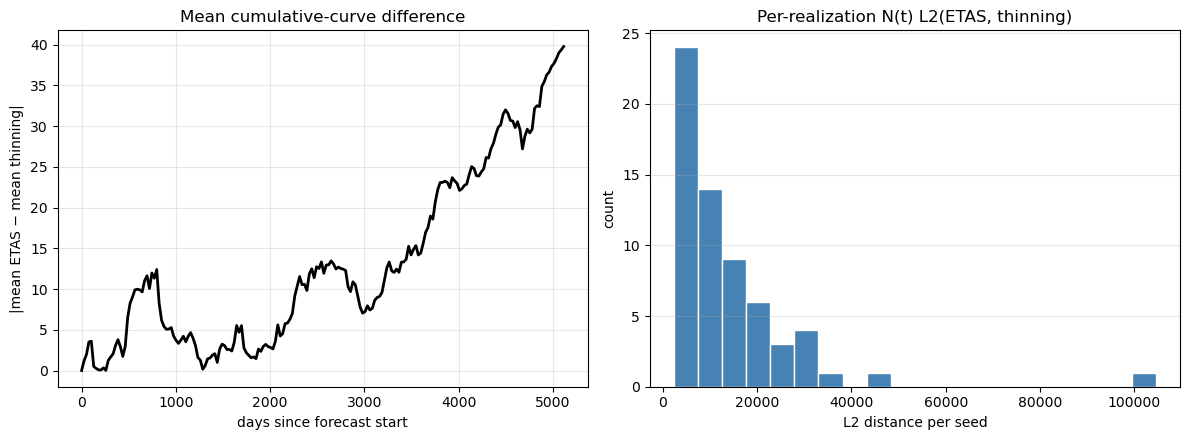

In [56]:
forecast_days = float(meta.get("forecast_days", np.nan))
if not np.isfinite(forecast_days):
    all_dt = np.concatenate([
        df["dt_days"].to_numpy()
        for catalogs in catalogs_by_seed.values()
        for df in catalogs.values()
    ])
    forecast_days = float(np.nanmax(all_dt)) if all_dt.size else 1.0

t_grid = np.linspace(0.0, forecast_days, 200)
etas_curves = np.vstack([
    cumulative_on_grid(etas_by_seed[s]["dt_days"].to_numpy(), t_grid)
    for s in selected_seeds
])
thin_curves = np.vstack([
    cumulative_on_grid(thinning_by_seed[s]["dt_days"].to_numpy(), t_grid)
    for s in selected_seeds
])

# --- cumulative N(t): mean with 25–75% band ---
fig, ax = plt.subplots(figsize=(10, 5.5))
for label, arr, color in [
    ("ETAS", etas_curves, ETAS_COLOR),
    ("Thinning", thin_curves, THINNING_COLOR),
]:
    mean = arr.mean(axis=0)
    if arr.shape[0] > 1:
        q25, q75 = np.quantile(arr, [0.25, 0.75], axis=0)
    else:
        q25 = q75 = mean
    ax.fill_between(t_grid, q25, q75, color=color, alpha=0.2, zorder=2)
    ax.plot(
        t_grid,
        mean,
        color=color,
        lw=2.0,
        zorder=3,
        label=f"{label} mean (25–75% band, n={arr.shape[0]})",
    )
ax.set_xlabel("days since forecast start")
ax.set_ylabel("cumulative number of events N(t)")
ax.set_title("Cumulative event count across realizations")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

# --- events per time bin (not cumulative) ---
n_bins = 40
bin_edges = np.linspace(0.0, forecast_days, n_bins + 1)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
etas_bin_curves = np.vstack([
    events_per_time_bin(etas_by_seed[s]["dt_days"].to_numpy(), bin_edges)
    for s in selected_seeds
])
thin_bin_curves = np.vstack([
    events_per_time_bin(thinning_by_seed[s]["dt_days"].to_numpy(), bin_edges)
    for s in selected_seeds
])

fig, ax = plt.subplots(figsize=(10, 5.5))
for label, arr, color in [
    ("ETAS", etas_bin_curves, ETAS_COLOR),
    ("Thinning", thin_bin_curves, THINNING_COLOR),
]:
    mean = arr.mean(axis=0)
    ax.plot(bin_centers, mean, color=color, lw=2.0, label=f"{label} mean per bin")
ax.set_xlabel("days since forecast start")
ax.set_ylabel("events per time bin")
ax.set_title(f"Event rate by time bin ({n_bins} equal-width bins)")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

# --- N(t) curve diagnostics across seeds ---
mean_diff = np.abs(etas_curves.mean(axis=0) - thin_curves.mean(axis=0))
l2_per_seed = [
    l2_curve_distance(etas_curves[i], thin_curves[i], t_grid)
    for i in range(len(selected_seeds))
]
nt_curve_summary = pd.DataFrame({
    "metric": [
        "max |mean ETAS − mean thinning| on t grid",
        "mean |mean ETAS − mean thinning| on t grid",
        "median per-seed L2(ETAS, thinning)",
        "mean per-seed L2(ETAS, thinning)",
    ],
    "value": [
        float(mean_diff.max()),
        float(mean_diff.mean()),
        float(np.median(l2_per_seed)),
        float(np.mean(l2_per_seed)),
    ],
})
display(Markdown("**N(t) curve agreement (across loaded seeds):**"))
display(nt_curve_summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(t_grid, mean_diff, color="black", lw=2.0)
axes[0].set_xlabel("days since forecast start")
axes[0].set_ylabel("|mean ETAS − mean thinning|")
axes[0].set_title("Mean cumulative-curve difference")
axes[0].grid(True, alpha=0.3)

axes[1].hist(l2_per_seed, bins=min(20, max(5, len(l2_per_seed) // 2)), color="steelblue", edgecolor="white")
axes[1].set_xlabel("L2 distance per seed")
axes[1].set_ylabel("count")
axes[1].set_title("Per-realization N(t) L2(ETAS, thinning)")
axes[1].grid(True, alpha=0.3, axis="y")
fig.tight_layout()
plt.show()


**Tier 1 — ensemble scalar summary:**

,metric,value
0,Pearson r (ETAS vs thinning counts),-0.004631
1,median thinning/ETAS ratio,0.952526
2,median |relative count error|,0.174929
3,median |Δ median dt| [days],252.637790
4,median |Δ max magnitude|,0.585744


,seed,etas_n_events,thinning_n_events,etas_background,thinning_background,etas_triggered,thinning_triggered,etas_median_dt_days,thinning_median_dt_days,etas_max_magnitude,thinning_max_magnitude,thinning_over_etas_ratio,delta_n,rel_delta_n,etas_bg_frac,thin_bg_frac
0,0,1453,2127,231,223,1222,1904,2477.095903,2550.238429,7.270355,8.229553,1.463868,674,0.463868,0.158981,0.104843
1,1,1491,1156,225,238,1266,918,2952.971184,2301.704275,6.829795,6.457294,0.775319,-335,-0.224681,0.150905,0.205882
2,2,1445,1254,226,247,1219,1007,2674.968949,2335.381538,6.710289,6.458501,0.867820,-191,-0.132180,0.156401,0.196970
3,3,1215,1394,231,227,984,1167,2655.772054,2500.158963,6.262460,6.651272,1.147325,179,0.147325,0.190123,0.162841
4,4,1167,1420,238,226,929,1194,2807.328342,2381.406609,7.150089,6.822966,1.216795,253,0.216795,0.203942,0.159155
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58,58,1203,1219,223,259,980,960,2427.745213,2155.701666,6.397693,6.672329,1.013300,16,0.013300,0.185370,0.212469
59,59,1351,1078,256,207,1095,871,2948.378784,2887.012632,6.871199,6.454972,0.797927,-273,-0.202073,0.189489,0.192022
60,60,1422,1580,220,241,1202,1339,2634.107501,2286.669972,7.098236,7.116100,1.111111,158,0.111111,0.154712,0.152532
61,61,1445,1126,245,247,1200,879,2745.189316,2468.443093,7.123067,5.965610,0.779239,-319,-0.220761,0.169550,0.219361


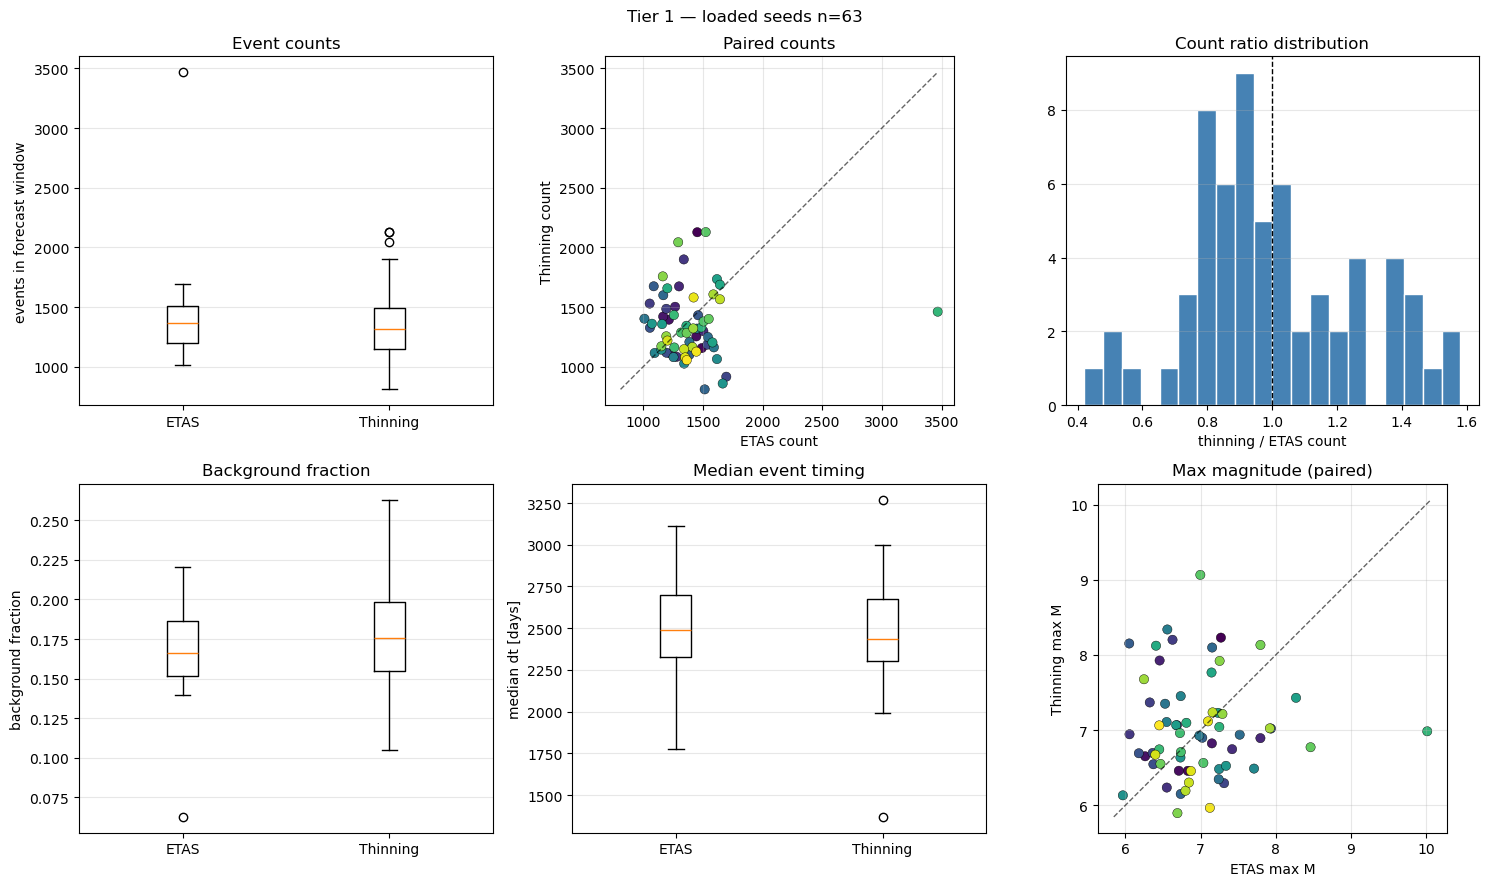

In [57]:
# --- Tier 1: scalar summaries (metrics_df is computed on disk or in memory) ---
metrics_df = metrics_df.copy()
metrics_df["delta_n"] = metrics_df["thinning_n_events"] - metrics_df["etas_n_events"]
metrics_df["rel_delta_n"] = metrics_df["delta_n"] / metrics_df["etas_n_events"].replace(0, np.nan)
metrics_df["etas_bg_frac"] = metrics_df["etas_background"] / metrics_df["etas_n_events"].replace(0, np.nan)
metrics_df["thin_bg_frac"] = metrics_df["thinning_background"] / metrics_df["thinning_n_events"].replace(0, np.nan)

tier1_summary = pd.DataFrame({
    "metric": [
        "Pearson r (ETAS vs thinning counts)",
        "median thinning/ETAS ratio",
        "median |relative count error|",
        "median |Δ median dt| [days]",
        "median |Δ max magnitude|",
    ],
    "value": [
        float(metrics_df[["etas_n_events", "thinning_n_events"]].corr().iloc[0, 1]),
        float(metrics_df["thinning_over_etas_ratio"].median()),
        float(metrics_df["rel_delta_n"].abs().median()),
        float((metrics_df["thinning_median_dt_days"] - metrics_df["etas_median_dt_days"]).abs().median()),
        float((metrics_df["thinning_max_magnitude"] - metrics_df["etas_max_magnitude"]).abs().median()),
    ],
})
display(Markdown("**Tier 1 — ensemble scalar summary:**"))
display(tier1_summary)
display(metrics_df)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

axes[0, 0].boxplot(
    [metrics_df["etas_n_events"], metrics_df["thinning_n_events"]],
    tick_labels=["ETAS", "Thinning"],
)
axes[0, 0].set_ylabel("events in forecast window")
axes[0, 0].set_title("Event counts")
axes[0, 0].grid(True, alpha=0.3, axis="y")

axes[0, 1].scatter(
    metrics_df["etas_n_events"],
    metrics_df["thinning_n_events"],
    c=metrics_df["seed"],
    cmap="viridis",
    s=45,
    edgecolors="black",
    linewidths=0.3,
)
lo = min(metrics_df["etas_n_events"].min(), metrics_df["thinning_n_events"].min())
hi = max(metrics_df["etas_n_events"].max(), metrics_df["thinning_n_events"].max())
axes[0, 1].plot([lo, hi], [lo, hi], "k--", lw=1.0, alpha=0.6)
axes[0, 1].set_xlabel("ETAS count")
axes[0, 1].set_ylabel("Thinning count")
axes[0, 1].set_title("Paired counts")
axes[0, 1].set_aspect("equal", adjustable="box")
axes[0, 1].grid(True, alpha=0.3)

axes[0, 2].hist(
    metrics_df["thinning_over_etas_ratio"].dropna(),
    bins=min(20, max(5, len(metrics_df) // 2)),
    color="steelblue",
    edgecolor="white",
)
axes[0, 2].axvline(1.0, color="black", ls="--", lw=1.0)
axes[0, 2].set_xlabel("thinning / ETAS count")
axes[0, 2].set_title("Count ratio distribution")
axes[0, 2].grid(True, alpha=0.3, axis="y")

axes[1, 0].boxplot(
    [metrics_df["etas_bg_frac"].dropna(), metrics_df["thin_bg_frac"].dropna()],
    tick_labels=["ETAS", "Thinning"],
)
axes[1, 0].set_ylabel("background fraction")
axes[1, 0].set_title("Background fraction")
axes[1, 0].grid(True, alpha=0.3, axis="y")

axes[1, 1].boxplot(
    [metrics_df["etas_median_dt_days"], metrics_df["thinning_median_dt_days"]],
    tick_labels=["ETAS", "Thinning"],
)
axes[1, 1].set_ylabel("median dt [days]")
axes[1, 1].set_title("Median event timing")
axes[1, 1].grid(True, alpha=0.3, axis="y")

axes[1, 2].scatter(
    metrics_df["etas_max_magnitude"],
    metrics_df["thinning_max_magnitude"],
    c=metrics_df["seed"],
    cmap="viridis",
    s=45,
    edgecolors="black",
    linewidths=0.3,
)
lo_m = min(metrics_df["etas_max_magnitude"].min(), metrics_df["thinning_max_magnitude"].min()) - 0.05
hi_m = max(metrics_df["etas_max_magnitude"].max(), metrics_df["thinning_max_magnitude"].max()) + 0.05
axes[1, 2].plot([lo_m, hi_m], [lo_m, hi_m], "k--", lw=1.0, alpha=0.6)
axes[1, 2].set_xlabel("ETAS max M")
axes[1, 2].set_ylabel("Thinning max M")
axes[1, 2].set_title("Max magnitude (paired)")
axes[1, 2].set_aspect("equal", adjustable="box")
axes[1, 2].grid(True, alpha=0.3)

fig.suptitle(f"Tier 1 — loaded seeds n={len(selected_seeds)}", fontsize=12)
fig.tight_layout()
plt.show()


2026-06-26 20:10:59,946 - DEBUG - Loaded backend inline version unknown.


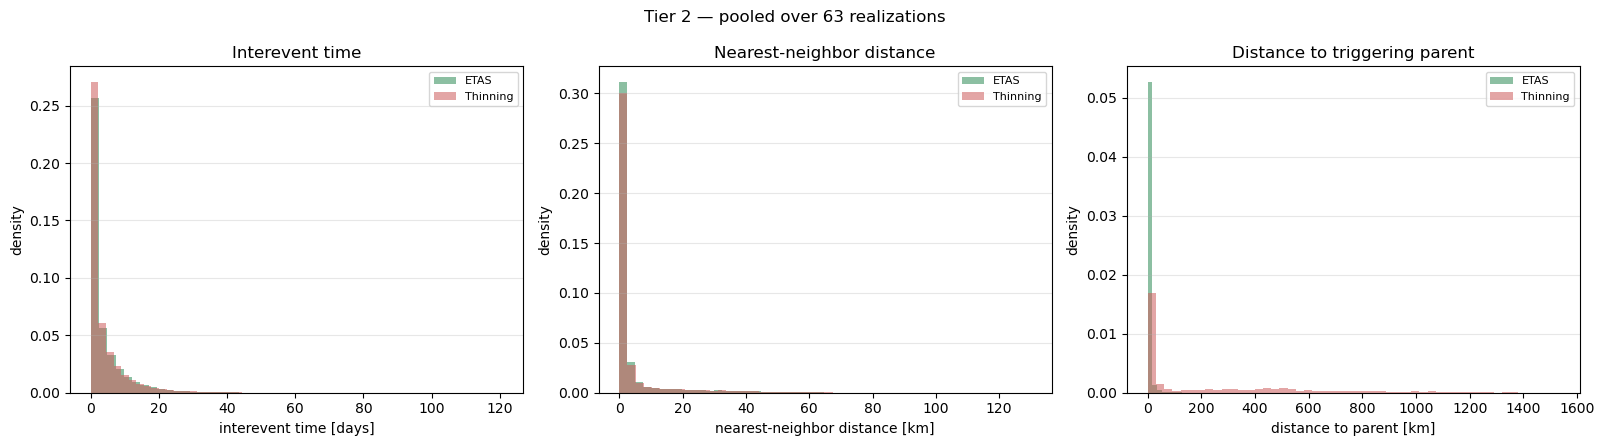

2026-06-26 20:11:00,162 - DEBUG - vmin 0.03405529813805126 vmax 52.670912050479714
2026-06-26 20:11:00,162 - DEBUG - ticklocs array([1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03])
2026-06-26 20:11:00,163 - DEBUG - vmin 0.03405529813805126 vmax 52.670912050479714
2026-06-26 20:11:00,163 - DEBUG - ticklocs array([2.e-03, 3.e-03, 4.e-03, 5.e-03, 6.e-03, 7.e-03, 8.e-03, 9.e-03,
       2.e-02, 3.e-02, 4.e-02, 5.e-02, 6.e-02, 7.e-02, 8.e-02, 9.e-02,
       2.e-01, 3.e-01, 4.e-01, 5.e-01, 6.e-01, 7.e-01, 8.e-01, 9.e-01,
       2.e+00, 3.e+00, 4.e+00, 5.e+00, 6.e+00, 7.e+00, 8.e+00, 9.e+00,
       2.e+01, 3.e+01, 4.e+01, 5.e+01, 6.e+01, 7.e+01, 8.e+01, 9.e+01,
       2.e+02, 3.e+02, 4.e+02, 5.e+02, 6.e+02, 7.e+02, 8.e+02, 9.e+02,
       2.e+03, 3.e+03, 4.e+03, 5.e+03, 6.e+03, 7.e+03, 8.e+03, 9.e+03])
2026-06-26 20:11:00,164 - DEBUG - vmin 0.03405529813805126 vmax 52.670912050479714
2026-06-26 20:11:00,164 - DEBUG - ticklocs array([1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+0

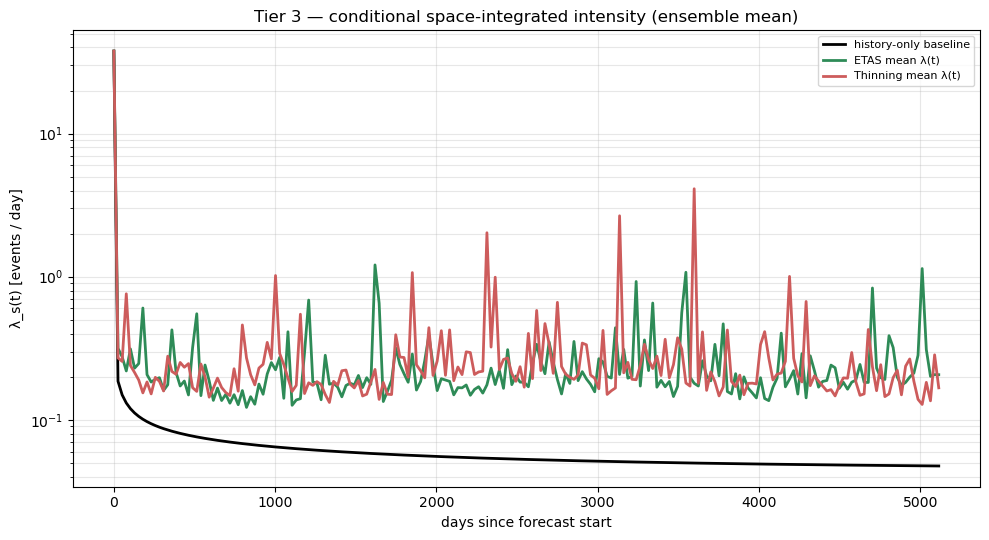

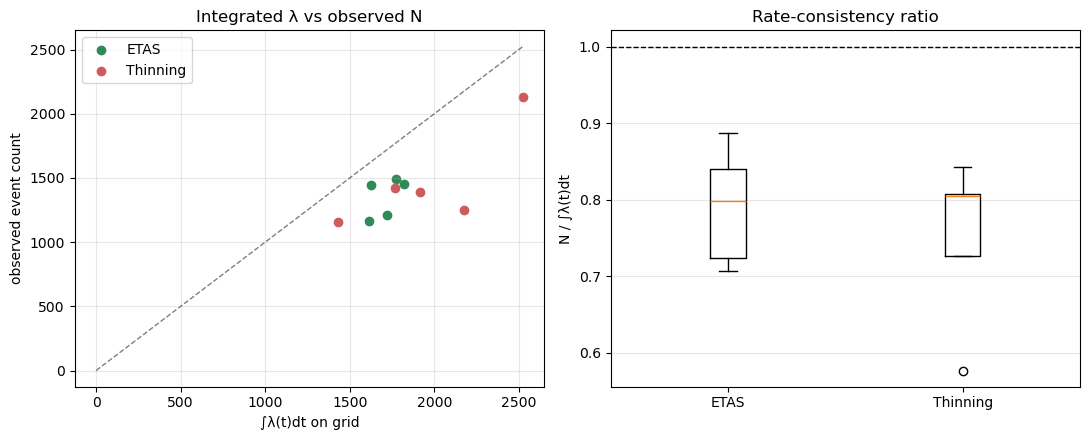

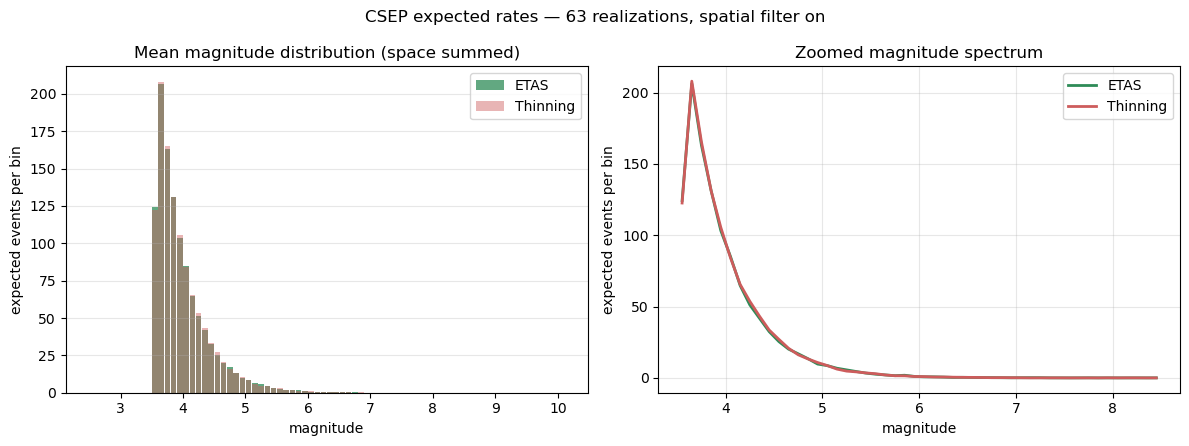

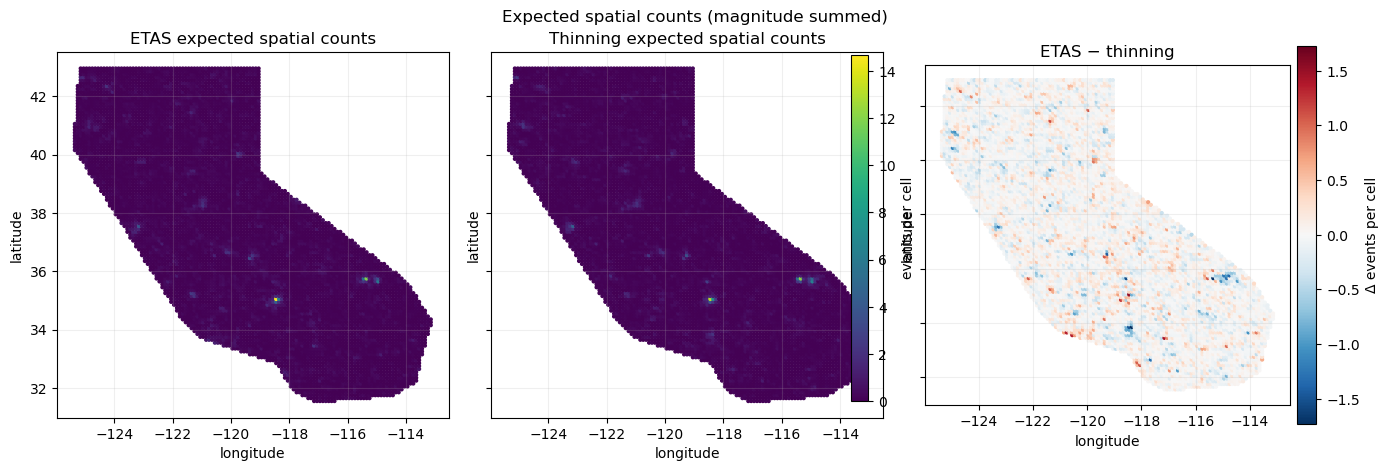

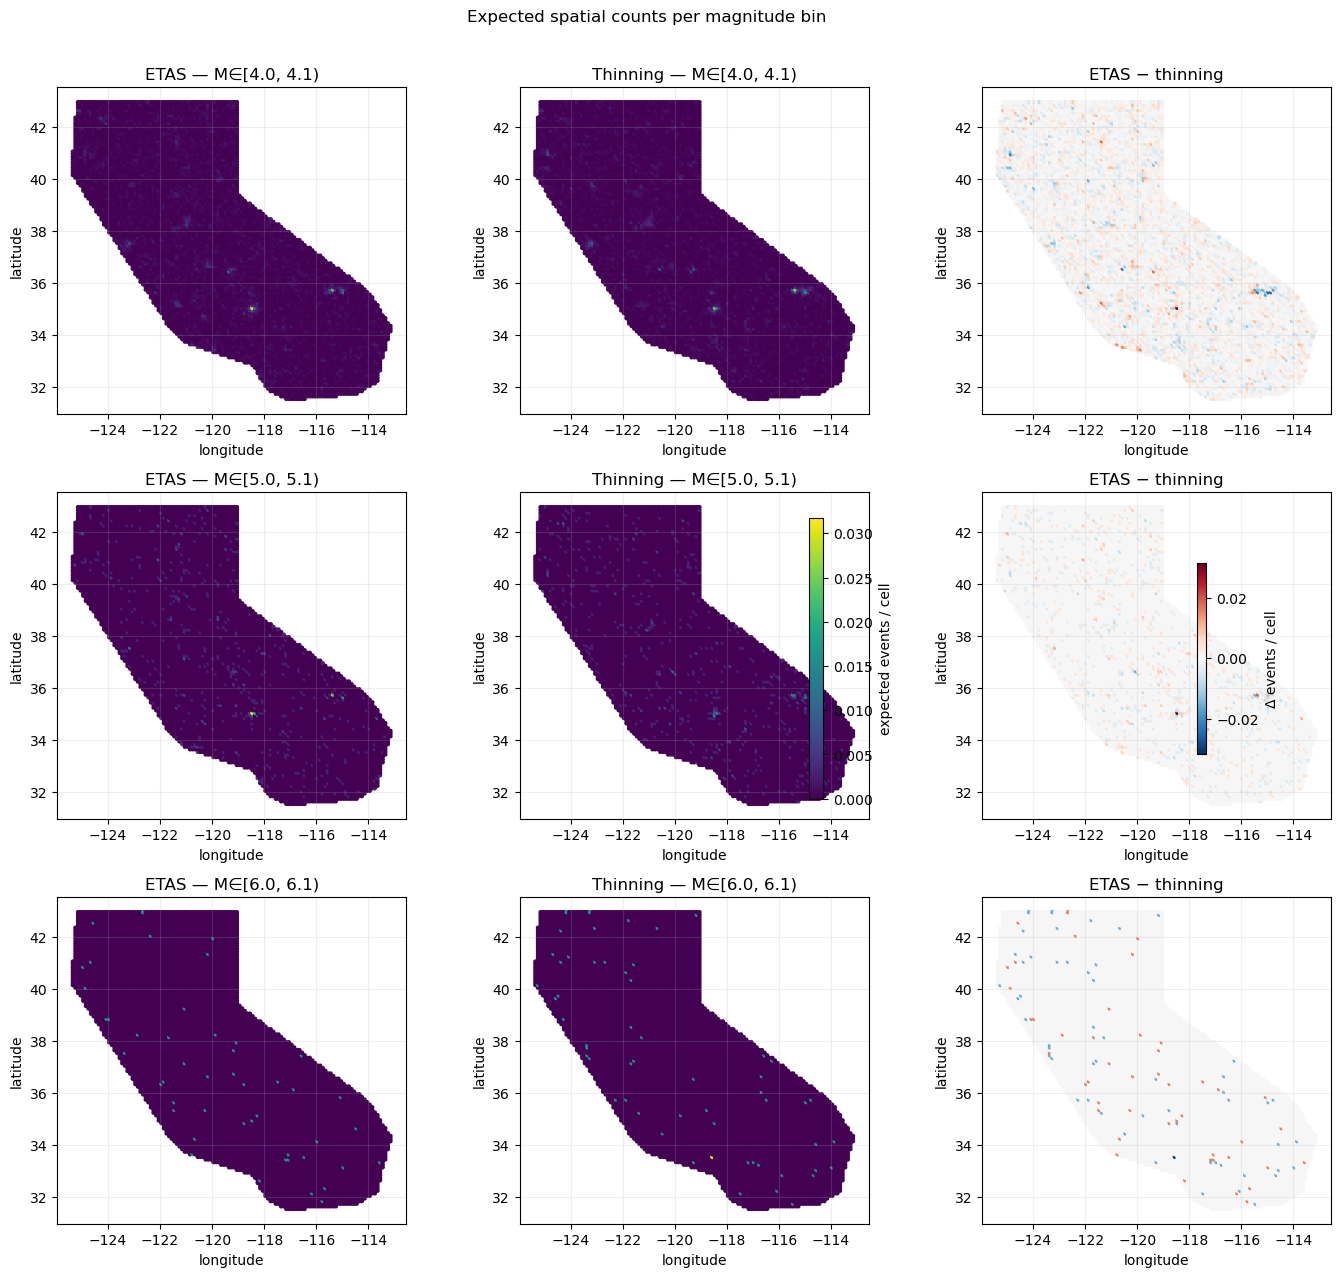

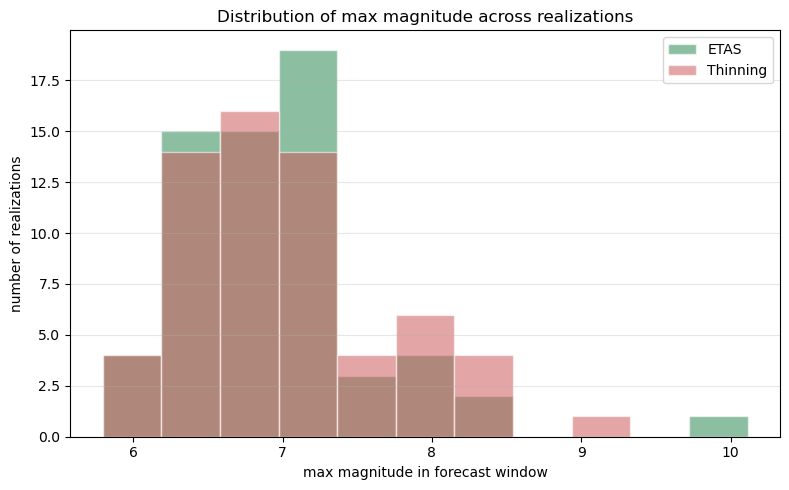

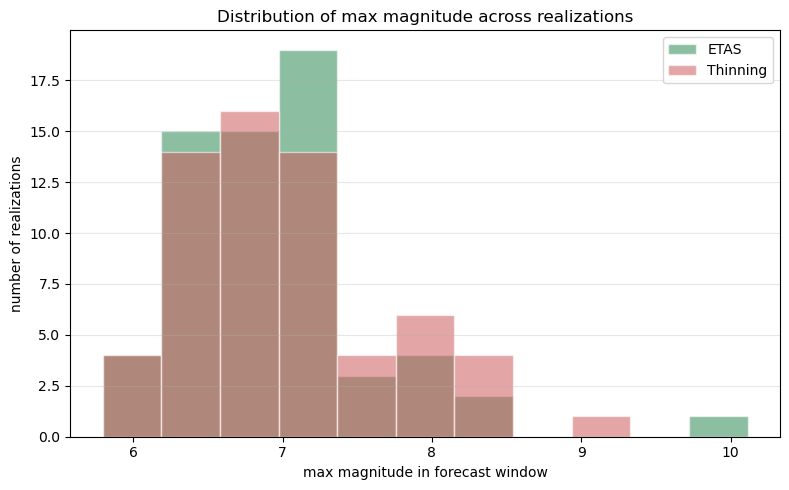

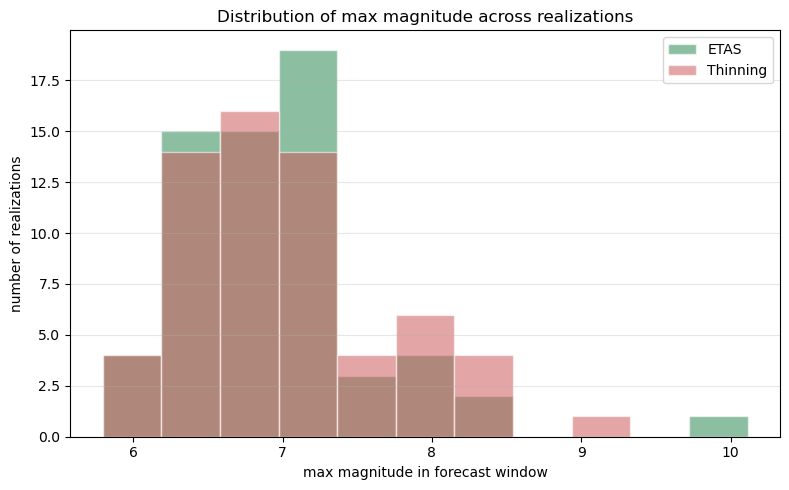

In [69]:
%matplotlib inline

# Max magnitude distribution across realizations (Tier 1)
m_lo = min(metrics_df["etas_max_magnitude"].min(), metrics_df["thinning_max_magnitude"].min()) - 0.1
m_hi = max(metrics_df["etas_max_magnitude"].max(), metrics_df["thinning_max_magnitude"].max()) + 0.1
mag_bins = np.linspace(m_lo, m_hi, 12)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(
    metrics_df["etas_max_magnitude"],
    bins=mag_bins,
    alpha=0.55,
    color=ETAS_COLOR,
    label="ETAS",
    edgecolor="white",
)
ax.hist(
    metrics_df["thinning_max_magnitude"],
    bins=mag_bins,
    alpha=0.55,
    color=THINNING_COLOR,
    label="Thinning",
    edgecolor="white",
)
ax.set_xlabel("max magnitude in forecast window")
ax.set_ylabel("number of realizations")
ax.set_title("Distribution of max magnitude across realizations")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
fig.tight_layout()
plt.show()


### Tier 2 — distributional comparisons

Pooled across all loaded realizations: interevent-time PDFs, nearest-neighbor distances, and distance to triggering parent (ETAS: stored parent coordinates; thinning: dominant parent at event time).

In [58]:
etas_iet, thin_iet = [], []
etas_nn, thin_nn = [], []
etas_parent, thin_parent = [], []

intensity_ctx = load_intensity_context(ensemble_dir, meta, selected_seeds[0])
# Dominant-parent distance for thinning is expensive (A_h per prior event); use a small subset.
thin_parent_seeds = selected_seeds[: min(3, len(selected_seeds))]
if len(thin_parent_seeds) < len(selected_seeds):
    print(f"Thinning parent distances: using seeds {thin_parent_seeds} (subset for speed).")

for seed in selected_seeds:
    etas_cat = etas_by_seed[seed]
    thin_cat = thinning_by_seed[seed]
    etas_iet.append(interevent_times(etas_cat["dt_days"].to_numpy()))
    thin_iet.append(interevent_times(thin_cat["dt_days"].to_numpy()))
    etas_nn.append(nearest_neighbor_distances_km(etas_cat))
    thin_nn.append(nearest_neighbor_distances_km(thin_cat))
    etas_parent.append(etas_parent_distances_km(etas_cat))
    if seed in thin_parent_seeds:
        ctx_seed = {**intensity_ctx, "hist_events": list(intensity_ctx["hist_events"])}
        thin_parent.append(thinning_dominant_parent_distances_km(thin_cat, ctx_seed))

etas_iet_all = np.concatenate(etas_iet) if etas_iet else np.array([])
thin_iet_all = np.concatenate(thin_iet) if thin_iet else np.array([])
etas_nn_all = np.concatenate(etas_nn) if etas_nn else np.array([])
thin_nn_all = np.concatenate(thin_nn) if thin_nn else np.array([])
etas_parent_all = np.concatenate(etas_parent) if etas_parent else np.array([])
thin_parent_all = np.concatenate(thin_parent) if thin_parent else np.array([])

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, etas_data, thin_data, xlabel, title in [
    (axes[0], etas_iet_all, thin_iet_all, "interevent time [days]", "Interevent time"),
    (axes[1], etas_nn_all, thin_nn_all, "nearest-neighbor distance [km]", "Nearest-neighbor distance"),
    (axes[2], etas_parent_all, thin_parent_all, "distance to parent [km]", "Distance to triggering parent"),
]:
    if etas_data.size:
        ax.hist(etas_data, bins=50, density=True, alpha=0.55, color=ETAS_COLOR, label="ETAS")
    if thin_data.size:
        ax.hist(thin_data, bins=50, density=True, alpha=0.55, color=THINNING_COLOR, label="Thinning")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("density")
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis="y")

fig.suptitle(f"Tier 2 — pooled over {len(selected_seeds)} realizations", fontsize=12)
fig.tight_layout()
plt.show()

tier2_ks = []
for name, etas_data, thin_data in [
    ("interevent time", etas_iet_all, thin_iet_all),
    ("nearest-neighbor distance", etas_nn_all, thin_nn_all),
    ("parent distance", etas_parent_all, thin_parent_all),
]:
    if etas_data.size and thin_data.size:
        stat, pval = stats.ks_2samp(etas_data, thin_data)
        tier2_ks.append({"comparison": name, "KS statistic": stat, "p-value": pval})
if tier2_ks:
    display(Markdown("**Tier 2 — pooled KS tests (ETAS vs thinning):**"))
    display(pd.DataFrame(tier2_ks))


2026-06-26 19:44:47,048 - DEBUG - Loaded backend Agg version v2.2.
2026-06-26 19:44:47,049 - INFO - Loading Calculation...
2026-06-26 19:44:47,049 - INFO -   model is named NoName ETAS Model, has ID c0b4eb6d6e4a24f1
2026-06-26 19:44:47,050 - INFO -   Time Window: 
      1971-01-01 00:00:00 (aux start)
      1981-01-01 00:00:00 (start)
      2007-01-01 00:00:00 (end).
2026-06-26 19:44:47,050 - INFO -   free_productivity: False, free_background: False
2026-06-26 19:44:47,060 - INFO -   3303 out of 4454 events are within time window.
2026-06-26 19:44:47,061 - INFO -   Coordinates of region: [array([  43.5, -125.7]), array([  43.5, -118.5]), array([  39.7, -118.5]), array([  36.1, -113.6]), array([  34.6, -112.6]), array([  34.3, -112.6]), array([  32.7, -113.1]), array([  31.8, -113.2]), array([  31.2, -114.5]), array([  31. , -117.1]), array([  31.1, -117.4]), array([  31.5, -118.3]), array([  32.4, -118.8]), array([  33.3, -121.3]), array([  34., -122.]), array([  37.5, -124.3]), array(

**Tier 2 — pooled KS tests (ETAS vs thinning):**

,comparison,KS statistic,p-value
0,interevent time,0.006359,0.061057
1,nearest-neighbor distance,0.004853,0.261067
2,parent distance,0.498193,0.000000


### Tier 3 — mechanistic checks

Conditional space-integrated intensity λ(t) (history baseline + each method's full catalog) and rate consistency: ∫λ(t)dt versus observed event count. Uses inversion parameters for the loaded ensemble.

In [59]:
if "intensity_ctx" not in globals():
    intensity_ctx = load_intensity_context(ensemble_dir, meta, selected_seeds[0])

ctx = intensity_ctx
cat_cmp = ctx["module"]
t_abs_grid = np.linspace(ctx["forecast_start_t"], ctx["forecast_end_t"], 200)
dt_grid = t_abs_grid - ctx["forecast_start_t"]
lam_hist = np.array([
    cat_cmp.lambda_s_total(t, ctx["hist_events"], ctx["polygon"], ctx["theta_0"], ctx["a_h_resolution"])
    for t in t_abs_grid
])

# λ(t) is expensive; evaluate on a small seed subset for the ensemble-mean curves.
lambda_seeds = selected_seeds[: min(5, len(selected_seeds))]
if len(lambda_seeds) < len(selected_seeds):
    print(f"λ(t) plots: using seeds {lambda_seeds} (subset for speed).")

lam_etas_seeds, lam_thin_seeds = [], []
rate_rows = []
for seed in lambda_seeds:
    etas_cat = etas_by_seed[seed]
    thin_cat = thinning_by_seed[seed]
    lam_e = lambda_on_grid(etas_cat, ctx, t_abs_grid)
    lam_t = lambda_on_grid(thin_cat, ctx, t_abs_grid)
    lam_etas_seeds.append(lam_e)
    lam_thin_seeds.append(lam_t)
    int_e = integrated_lambda(lam_e, t_abs_grid)
    int_t = integrated_lambda(lam_t, t_abs_grid)
    rate_rows.append({
        "seed": seed,
        "etas_n": len(etas_cat),
        "thin_n": len(thin_cat),
        "etas_trapz_lambda": int_e,
        "thin_trapz_lambda": int_t,
        "etas_n_over_trapz": len(etas_cat) / int_e if int_e > 0 else np.nan,
        "thin_n_over_trapz": len(thin_cat) / int_t if int_t > 0 else np.nan,
    })

lam_etas_mean = np.mean(lam_etas_seeds, axis=0)
lam_thin_mean = np.mean(lam_thin_seeds, axis=0)
rate_consistency_df = pd.DataFrame(rate_rows)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(dt_grid, lam_hist, color="black", lw=2.0, label="history-only baseline")
ax.plot(dt_grid, lam_etas_mean, color=ETAS_COLOR, lw=2.0, label="ETAS mean λ(t)")
ax.plot(dt_grid, lam_thin_mean, color=THINNING_COLOR, lw=2.0, label="Thinning mean λ(t)")
ax.set_yscale("log")
ax.set_xlabel("days since forecast start")
ax.set_ylabel("λ_s(t) [events / day]")
ax.set_title("Tier 3 — conditional space-integrated intensity (ensemble mean)")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

display(Markdown("**Tier 3 — spatial integral / rate consistency (per seed):**"))
display(rate_consistency_df.describe().T[["mean", "50%", "std"]].rename(columns={"50%": "median"}))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].scatter(rate_consistency_df["etas_trapz_lambda"], rate_consistency_df["etas_n"], c=ETAS_COLOR, label="ETAS")
axes[0].scatter(rate_consistency_df["thin_trapz_lambda"], rate_consistency_df["thin_n"], c=THINNING_COLOR, label="Thinning")
mx = max(rate_consistency_df[["etas_trapz_lambda", "thin_trapz_lambda", "etas_n", "thin_n"]].max())
axes[0].plot([0, mx], [0, mx], "k--", lw=1.0, alpha=0.5)
axes[0].set_xlabel("∫λ(t)dt on grid")
axes[0].set_ylabel("observed event count")
axes[0].set_title("Integrated λ vs observed N")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].boxplot(
    [rate_consistency_df["etas_n_over_trapz"].dropna(), rate_consistency_df["thin_n_over_trapz"].dropna()],
    tick_labels=["ETAS", "Thinning"],
)
axes[1].axhline(1.0, color="black", ls="--", lw=1.0)
axes[1].set_ylabel("N / ∫λ(t)dt")
axes[1].set_title("Rate-consistency ratio")
axes[1].grid(True, alpha=0.3, axis="y")
fig.tight_layout()
plt.show()


λ(t) plots: using seeds [0, 1, 2, 3, 4] (subset for speed).
2026-06-26 19:56:03,032 - DEBUG - vmin 0.03405529813805126 vmax 52.670912050479714
2026-06-26 19:56:03,034 - DEBUG - ticklocs array([1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03])
2026-06-26 19:56:03,037 - DEBUG - vmin 0.03405529813805126 vmax 52.670912050479714
2026-06-26 19:56:03,038 - DEBUG - ticklocs array([2.e-03, 3.e-03, 4.e-03, 5.e-03, 6.e-03, 7.e-03, 8.e-03, 9.e-03,
       2.e-02, 3.e-02, 4.e-02, 5.e-02, 6.e-02, 7.e-02, 8.e-02, 9.e-02,
       2.e-01, 3.e-01, 4.e-01, 5.e-01, 6.e-01, 7.e-01, 8.e-01, 9.e-01,
       2.e+00, 3.e+00, 4.e+00, 5.e+00, 6.e+00, 7.e+00, 8.e+00, 9.e+00,
       2.e+01, 3.e+01, 4.e+01, 5.e+01, 6.e+01, 7.e+01, 8.e+01, 9.e+01,
       2.e+02, 3.e+02, 4.e+02, 5.e+02, 6.e+02, 7.e+02, 8.e+02, 9.e+02,
       2.e+03, 3.e+03, 4.e+03, 5.e+03, 6.e+03, 7.e+03, 8.e+03, 9.e+03])
2026-06-26 19:56:03,038 - DEBUG - vmin 0.03405529813805126 vmax 52.670912050479714
2026-06-26 19:56:03,039 - DEBUG - ticklocs 

**Tier 3 — spatial integral / rate consistency (per seed):**

,mean,median,std
seed,2.000000,2.000000,1.581139
etas_n,1354.200000,1445.000000,150.947673
thin_n,1470.200000,1394.000000,382.484248
etas_trapz_lambda,1710.730525,1718.188440,90.821643
thin_trapz_lambda,1962.413033,1918.401966,413.000722
etas_n_over_trapz,0.791364,0.797906,0.076270
thin_n_over_trapz,0.751686,0.804610,0.106441


2026-06-26 19:56:09,320 - DEBUG - vmin 0.03405529813805126 vmax 52.670912050479714
2026-06-26 19:56:09,321 - DEBUG - ticklocs array([1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03])
2026-06-26 19:56:09,321 - DEBUG - vmin 0.03405529813805126 vmax 52.670912050479714
2026-06-26 19:56:09,322 - DEBUG - ticklocs array([2.e-03, 3.e-03, 4.e-03, 5.e-03, 6.e-03, 7.e-03, 8.e-03, 9.e-03,
       2.e-02, 3.e-02, 4.e-02, 5.e-02, 6.e-02, 7.e-02, 8.e-02, 9.e-02,
       2.e-01, 3.e-01, 4.e-01, 5.e-01, 6.e-01, 7.e-01, 8.e-01, 9.e-01,
       2.e+00, 3.e+00, 4.e+00, 5.e+00, 6.e+00, 7.e+00, 8.e+00, 9.e+00,
       2.e+01, 3.e+01, 4.e+01, 5.e+01, 6.e+01, 7.e+01, 8.e+01, 9.e+01,
       2.e+02, 3.e+02, 4.e+02, 5.e+02, 6.e+02, 7.e+02, 8.e+02, 9.e+02,
       2.e+03, 3.e+03, 4.e+03, 5.e+03, 6.e+03, 7.e+03, 8.e+03, 9.e+03])
2026-06-26 19:56:09,322 - DEBUG - vmin 0.03405529813805126 vmax 52.670912050479714
2026-06-26 19:56:09,322 - DEBUG - ticklocs array([1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+0

### Formal statistical tests

Paired tests respect the shared random seed per realization. Pooled KS tests concatenate all loaded events (unpaired). Permutation test shuffles method labels on paired count differences.

In [60]:
if "intensity_ctx" not in globals():
    intensity_ctx = load_intensity_context(ensemble_dir, meta, selected_seeds[0])

etas_counts = metrics_df["etas_n_events"].to_numpy()
thin_counts = metrics_df["thinning_n_events"].to_numpy()
paired_diff = thin_counts - etas_counts

# Paired Wilcoxon signed-rank on event counts
wilcoxon_stat, wilcoxon_p = stats.wilcoxon(thin_counts, etas_counts)

# Pearson correlation on paired counts
pearson_r, pearson_p = stats.pearsonr(etas_counts, thin_counts)

# Pooled KS on dt_days and magnitudes
etas_dt_pool = np.concatenate([
    etas_by_seed[s]["dt_days"].to_numpy(dtype=float) for s in selected_seeds
])
thin_dt_pool = np.concatenate([
    thinning_by_seed[s]["dt_days"].to_numpy(dtype=float) for s in selected_seeds
])
etas_dt_pool = etas_dt_pool[np.isfinite(etas_dt_pool)]
thin_dt_pool = thin_dt_pool[np.isfinite(thin_dt_pool)]

mc_val = float(intensity_ctx["mc"]) if "intensity_ctx" in globals() else np.nan
etas_m_pool = np.concatenate([etas_by_seed[s]["m"].to_numpy(dtype=float) for s in selected_seeds])
thin_m_pool = np.concatenate([thinning_by_seed[s]["m"].to_numpy(dtype=float) for s in selected_seeds])
if np.isfinite(mc_val):
    etas_m_pool = etas_m_pool[etas_m_pool >= mc_val]
    thin_m_pool = thin_m_pool[thin_m_pool >= mc_val]

ks_dt_stat, ks_dt_p = stats.ks_2samp(etas_dt_pool, thin_dt_pool)
ks_m_stat, ks_m_p = stats.ks_2samp(etas_m_pool, thin_m_pool)

# Per-seed KS on dt_days (summarize p-values)
per_seed_ks_dt = []
for seed in selected_seeds:
    e = etas_by_seed[seed]["dt_days"].to_numpy(dtype=float)
    t = thinning_by_seed[seed]["dt_days"].to_numpy(dtype=float)
    e, t = e[np.isfinite(e)], t[np.isfinite(t)]
    if e.size and t.size:
        stat, pval = stats.ks_2samp(e, t)
        per_seed_ks_dt.append({"seed": seed, "KS dt": stat, "p-value": pval})

# Permutation test on mean paired count difference
n_perm = 5000
rng = np.random.default_rng(0)
obs_mean_diff = paired_diff.mean()
perm_diffs = np.empty(n_perm)
for i in range(n_perm):
    signs = rng.choice([-1.0, 1.0], size=len(paired_diff))
    perm_diffs[i] = (signs * paired_diff).mean()
perm_p = float((np.abs(perm_diffs) >= abs(obs_mean_diff)).mean())

formal_results = pd.DataFrame([
    {"test": "Paired Wilcoxon (counts)", "statistic": wilcoxon_stat, "p-value": wilcoxon_p},
    {"test": "Pearson r (counts)", "statistic": pearson_r, "p-value": pearson_p},
    {"test": "KS pooled dt_days", "statistic": ks_dt_stat, "p-value": ks_dt_p},
    {"test": "KS pooled magnitude (≥ mc)", "statistic": ks_m_stat, "p-value": ks_m_p},
    {"test": "Permutation mean Δcount", "statistic": obs_mean_diff, "p-value": perm_p},
])
display(Markdown("**Formal tests:**"))
display(formal_results)

if per_seed_ks_dt:
    per_seed_ks_df = pd.DataFrame(per_seed_ks_dt)
    display(Markdown(
        f"**Per-seed KS on dt_days:** median p = {per_seed_ks_df['p-value'].median():.4f}, "
        f"fraction p>0.05 = {(per_seed_ks_df['p-value'] > 0.05).mean():.2%}"
    ))
    display(per_seed_ks_df.head(10))


**Formal tests:**

,test,statistic,p-value
0,Paired Wilcoxon (counts),915.000000,5.243198e-01
1,Pearson r (counts),-0.004631,9.712637e-01
2,KS pooled dt_days,0.014416,3.257747e-08
3,KS pooled magnitude (≥ mc),0.005761,1.137860e-01
4,Permutation mean Δcount,-39.777778,4.710000e-01


**Per-seed KS on dt_days:** median p = 0.0000, fraction p>0.05 = 3.17%

,seed,KS dt,p-value
0,0,0.150732,1.402769e-17
1,1,0.138342,2.475412e-11
2,2,0.125063,1.292662e-09
3,3,0.074354,1.423599e-03
4,4,0.097577,9.121405e-06
5,5,0.064953,1.373265e-02
6,6,0.175022,7.229418e-19
7,7,0.182180,1.074362e-21
8,8,0.125450,5.099469e-10
9,9,0.077103,1.737384e-03


In [61]:
import csep
from csep.core.catalogs import CSEPCatalog
from csep.core.forecasts import CatalogForecast
from csep.core.regions import california_relm_region, create_space_magnitude_region
from csep.utils.constants import CSEP_MW_BINS
from csep.utils.time_utils import datetime_to_utc_epoch


## CSEP expected rates from catalog forecasts

Treat each loaded realization as one synthetic catalog, wrap them in a `CatalogForecast`, and call `get_expected_rates()`:

1. Define a space–magnitude region (California RELM grid + CSEP magnitude bins).
2. Convert each pandas catalog to `CSEPCatalog`.
3. Bin every realization with `spatial_magnitude_counts()`, sum across realizations, divide by `n_cat`.

This mirrors `examples/tutorials/working_with_catalog_forecasts.py` in PyCSEP.

In [62]:
def _parse_forecast_window(meta: dict) -> tuple | None:
    """Return (start, end) if meta has both window endpoints, else None."""
    if not meta.get("timewindow_end") or not meta.get("testwindow_end"):
        return None
    start = pd.to_datetime(meta["timewindow_end"], utc=True).to_pydatetime()
    end = pd.to_datetime(meta["testwindow_end"], utc=True).to_pydatetime()
    return start, end


def forecast_window_from_meta(
    meta: dict,
    *,
    ensemble_dir: Path,
    seed: int,
    catalogs_by_seed: dict[int, dict[str, pd.DataFrame]],
) -> tuple:
    """Forecast interval: timewindow_end → testwindow_end (UTC-aware datetimes)."""
    window = _parse_forecast_window(meta)
    if window is not None:
        return window

    realization_meta_path = _realization_dir_for_seed(ensemble_dir, seed) / "realization_meta.json"
    if realization_meta_path.is_file():
        realization_meta = json.loads(realization_meta_path.read_text(encoding="utf-8"))
        window = _parse_forecast_window(realization_meta)
        if window is not None:
            print(f"Forecast window from {realization_meta_path.name} (seed={seed})")
            return window

    all_times = []
    for catalogs in catalogs_by_seed.values():
        for df in catalogs.values():
            if df.empty:
                continue
            if "time" in df.columns:
                all_times.append(pd.to_datetime(df["time"], utc=True))
            elif "t" in df.columns:
                all_times.append(
                    pd.Timestamp("1970-01-01", tz="UTC")
                    + pd.to_timedelta(df["t"], unit="D")
                )
    if all_times:
        times = pd.concat(all_times, ignore_index=True)
        print("Forecast window inferred from min/max event times in loaded catalogs")
        return times.min().to_pydatetime(), times.max().to_pydatetime()

    raise ValueError(
        "Could not determine forecast window: missing ensemble_meta.json, "
        "realization_meta.json, and catalog time columns."
    )


def _catalog_origin_time_epoch(df: pd.DataFrame) -> pd.Series:
    """Absolute event times as CSEP UTC epochs (ms)."""
    if "time" in df.columns:
        return pd.to_datetime(df["time"], utc=True).map(datetime_to_utc_epoch)
    if "t" in df.columns:
        epochs = pd.Timestamp("1970-01-01", tz="UTC") + pd.to_timedelta(df["t"], unit="D")
        return epochs.map(datetime_to_utc_epoch)
    raise KeyError("catalog needs a 'time' or 't' column for CSEP conversion")


def _catalog_coordinate_series(df: pd.DataFrame, *, primary: str, fallback: str) -> pd.Series:
    if primary in df.columns:
        return df[primary].astype(float)
    if fallback in df.columns:
        return df[fallback].astype(float)
    raise KeyError(f"catalog needs '{primary}' or '{fallback}'")


def dataframe_to_csep_catalog(
    df: pd.DataFrame,
    *,
    catalog_id: int,
    region,
) -> CSEPCatalog:
    """Map ensemble CSV columns to the CSEP catalog dtype."""
    csep_df = pd.DataFrame(
        {
            "id": [f"evt_{i}" for i in range(len(df))],
            "origin_time": _catalog_origin_time_epoch(df),
            "latitude": _catalog_coordinate_series(df, primary="latitude", fallback="y"),
            "longitude": _catalog_coordinate_series(df, primary="longitude", fallback="x"),
            "depth": np.zeros(len(df)),
            "magnitude": _catalog_coordinate_series(df, primary="magnitude", fallback="m"),
            "catalog_id": catalog_id,
        }
    )
    return CSEPCatalog.from_dataframe(csep_df, region=region)


def build_catalog_forecast(
    catalogs_by_seed: dict[int, pd.DataFrame],
    *,
    name: str,
    region,
    start_time,
    end_time,
    filter_spatial: bool = True,
) -> CatalogForecast:
    """One CatalogForecast from the loaded seed → catalog mapping."""
    seeds = sorted(catalogs_by_seed)
    catalogs = [
        dataframe_to_csep_catalog(catalogs_by_seed[seed], catalog_id=i, region=region)
        for i, seed in enumerate(seeds)
    ]
    return CatalogForecast(
        catalogs=catalogs,
        region=region,
        name=name,
        start_time=start_time,
        end_time=end_time,
        n_cat=len(catalogs),
        filter_spatial=filter_spatial,
        apply_filters=filter_spatial,
    )


# California RELM spatial grid with standard CSEP magnitude bin edges.
csep_region = create_space_magnitude_region(california_relm_region(), CSEP_MW_BINS)
forecast_start, forecast_end = forecast_window_from_meta(
    meta,
    ensemble_dir=ensemble_dir,
    seed=selected_seeds[0],
    catalogs_by_seed=catalogs_by_seed,
)

print(
    f"CSEP region: {csep_region.name}, "
    f"{csep_region.num_nodes} spatial cells, {len(csep_region.magnitudes)} magnitude bins"
)
print(f"Forecast window: {forecast_start} → {forecast_end}")


Forecast window from realization_meta.json (seed=0)
CSEP region: relm-california, 7682 spatial cells, 76 magnitude bins
Forecast window: 2007-01-01 00:00:00+00:00 → 2021-01-01 00:00:00+00:00


In [63]:
etas_catalog_forecast = build_catalog_forecast(
    etas_by_seed,
    name="ETAS ensemble",
    region=csep_region,
    start_time=forecast_start,
    end_time=forecast_end,
)
thin_catalog_forecast = build_catalog_forecast(
    thinning_by_seed,
    name="Thinning ensemble",
    region=csep_region,
    start_time=forecast_start,
    end_time=forecast_end,
)

etas_expected = etas_catalog_forecast.get_expected_rates(verbose=True)
thin_expected = thin_catalog_forecast.get_expected_rates(verbose=True)

etas_event_counts = etas_catalog_forecast.get_event_counts()
thin_event_counts = thin_catalog_forecast.get_event_counts()

summary = pd.DataFrame(
    {
        "method": ["ETAS", "Thinning"],
        "n_realizations": [etas_catalog_forecast.n_cat, thin_catalog_forecast.n_cat],
        "mean_events_per_catalog": [etas_event_counts.mean(), thin_event_counts.mean()],
        "mean_total_rate": [etas_expected.data.sum(), thin_expected.data.sum()],
    }
)
display(summary)
print(f"Expected-rate array shape (spatial × magnitude): {etas_expected.data.shape}")


Processed 1 catalogs in 0.005 seconds
Processed 2 catalogs in 0.011 seconds
Processed 3 catalogs in 0.015 seconds
Processed 4 catalogs in 0.017 seconds
Processed 5 catalogs in 0.018 seconds
Processed 6 catalogs in 0.019 seconds
Processed 7 catalogs in 0.021 seconds
Processed 8 catalogs in 0.022 seconds
Processed 9 catalogs in 0.024 seconds
Processed 10 catalogs in 0.025 seconds
Processed 20 catalogs in 0.036 seconds
Processed 30 catalogs in 0.046 seconds
Processed 40 catalogs in 0.057 seconds
Processed 50 catalogs in 0.069 seconds
Processed 60 catalogs in 0.080 seconds
Processed 1 catalogs in 0.003 seconds
Processed 2 catalogs in 0.006 seconds
Processed 3 catalogs in 0.010 seconds
Processed 4 catalogs in 0.012 seconds
Processed 5 catalogs in 0.013 seconds
Processed 6 catalogs in 0.014 seconds
Processed 7 catalogs in 0.016 seconds
Processed 8 catalogs in 0.017 seconds
Processed 9 catalogs in 0.018 seconds
Processed 10 catalogs in 0.020 seconds
Processed 20 catalogs in 0.030 seconds
Proc

,method,n_realizations,mean_events_per_catalog,mean_total_rate
0,ETAS,63,1130.984127,1130.984127
1,Thinning,63,1141.460317,1141.460317


Expected-rate array shape (spatial × magnitude): (7682, 76)


In [64]:
mag_bins = np.asarray(etas_expected.magnitudes, dtype=float)
dmw = mag_bins[1] - mag_bins[0]
mag_centers = mag_bins + dmw / 2

etas_mag_counts = etas_expected.magnitude_counts()
thin_mag_counts = thin_expected.magnitude_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(
    mag_centers,
    etas_mag_counts,
    width=dmw * 0.9,
    color=ETAS_COLOR,
    alpha=0.75,
    label="ETAS",
)
axes[0].bar(
    mag_centers,
    thin_mag_counts,
    width=dmw * 0.9,
    color=THINNING_COLOR,
    alpha=0.45,
    label="Thinning",
)
axes[0].set_xlabel("magnitude")
axes[0].set_ylabel("expected events per bin")
axes[0].set_title("Mean magnitude distribution (space summed)")
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis="y")

m_lo = max(2.5, float(min(etas_by_seed[s]["magnitude"].min() for s in selected_seeds)) - 0.1)
m_hi = min(8.5, float(max(etas_by_seed[s]["magnitude"].max() for s in selected_seeds)) + 0.1)
mask = (mag_centers >= m_lo) & (mag_centers <= m_hi)

axes[1].plot(mag_centers[mask], etas_mag_counts[mask], color=ETAS_COLOR, lw=2.0, label="ETAS")
axes[1].plot(mag_centers[mask], thin_mag_counts[mask], color=THINNING_COLOR, lw=2.0, label="Thinning")
axes[1].set_xlabel("magnitude")
axes[1].set_ylabel("expected events per bin")
axes[1].set_title("Zoomed magnitude spectrum")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.suptitle(
    f"CSEP expected rates — {len(selected_seeds)} realizations, spatial filter on",
    fontsize=12,
)
fig.tight_layout()
plt.show()


In [65]:
# Spatially aggregated expected rate per cell (M>=min magnitude), ETAS vs thinning.
etas_spatial = etas_expected.spatial_counts()
thin_spatial = thin_expected.spatial_counts()
lons, lats = csep_region.midpoints().T

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharex=True, sharey=True)
vmax = max(etas_spatial.max(), thin_spatial.max())

sc0 = axes[0].scatter(lons, lats, c=etas_spatial, s=4, cmap="viridis", vmin=0, vmax=vmax)
axes[0].set_title("ETAS expected spatial counts")
axes[1].scatter(lons, lats, c=thin_spatial, s=4, cmap="viridis", vmin=0, vmax=vmax)
axes[1].set_title("Thinning expected spatial counts")

diff = etas_spatial - thin_spatial
vabs = np.max(np.abs(diff))
sc2 = axes[2].scatter(
    lons,
    lats,
    c=diff,
    s=4,
    cmap="RdBu_r",
    vmin=-vabs,
    vmax=vabs,
)
axes[2].set_title("ETAS − thinning")

for ax in axes:
    ax.set_xlabel("longitude")
    ax.set_ylabel("latitude")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.2)

fig.colorbar(sc0, ax=axes[:2], fraction=0.03, pad=0.02, label="events per cell")
fig.colorbar(sc2, ax=axes[2], fraction=0.05, pad=0.02, label="Δ events per cell")
fig.suptitle("Expected spatial counts (magnitude summed)", fontsize=12)
fig.tight_layout()
plt.show()


2026-06-26 19:56:12,241 - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x793b7fbf4b10>
2026-06-26 19:56:12,247 - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x793b7dae3450>


/tmp/ipykernel_1351198/3684855696.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


## Spatial distribution for selected magnitude bin(s)

`expected_rates.data` has shape `(n_spatial, n_magnitude)`. Column `j` is the **expected event count per spatial cell** in magnitude bin `[m_j, m_j + Δm)`.

Summing column `j` over space recovers the marginal entry from `magnitude_counts()[j]` — the map below is the spatial **decomposition** of that marginal, not a different distribution.

In [66]:
# --- configure magnitude bin(s) to map ---
# Left edges from CSEP bins (e.g. 4.0 → events with 4.0 ≤ M < 4.1 when dmw=0.1).
MAG_BIN_LEFT_EDGES: list[float] | None = [4.0, 5.0, 6.0]

# Used only when MAG_BIN_LEFT_EDGES is None: sum all bins whose left edge lies in [lo, hi].
MAG_RANGE: tuple[float, float] = (4.0, 5.0)


def _mag_bin_indices(mag_left_edges: np.ndarray, targets: list[float]) -> list[int]:
    idx = []
    for m in targets:
        j = int(np.searchsorted(mag_left_edges, m, side="left"))
        if j >= len(mag_left_edges) or not np.isclose(mag_left_edges[j], m):
            raise ValueError(f"{m} is not a CSEP magnitude bin left edge; nearest bins: {mag_left_edges[max(j-1,0):j+2]}")
        idx.append(j)
    return idx


def expected_spatial_for_mag_bins(expected, mag_indices: list[int]) -> np.ndarray:
    """Sum expected spatial counts over the selected magnitude columns."""
    if not mag_indices:
        return np.zeros(expected.data.shape[0])
    return expected.data[:, mag_indices].sum(axis=1)


mag_left = np.asarray(etas_expected.magnitudes, dtype=float)
dmw = mag_left[1] - mag_left[0]

if MAG_BIN_LEFT_EDGES is not None:
    mag_targets = MAG_BIN_LEFT_EDGES
else:
    lo, hi = MAG_RANGE
    mag_targets = [m for m in mag_left if lo <= m <= hi]
    if not mag_targets:
        raise ValueError(f"No CSEP bins in MAG_RANGE={MAG_RANGE}")

mag_indices = _mag_bin_indices(mag_left, mag_targets)
lons, lats = csep_region.midpoints().T

n_rows = len(mag_targets)
fig, axes = plt.subplots(n_rows, 3, figsize=(14, 4.2 * n_rows), squeeze=False)

for row, (mag_edge, mag_idx) in enumerate(zip(mag_targets, mag_indices)):
    etas_slice = expected_spatial_for_mag_bins(etas_expected, [mag_idx])
    thin_slice = expected_spatial_for_mag_bins(thin_expected, [mag_idx])
    diff_slice = etas_slice - thin_slice

    vmax = max(etas_slice.max(), thin_slice.max(), 1e-12)
    vabs = max(np.abs(diff_slice).max(), 1e-12)

    sc0 = axes[row, 0].scatter(lons, lats, c=etas_slice, s=5, cmap="viridis", vmin=0, vmax=vmax)
    axes[row, 0].set_title(f"ETAS — M∈[{mag_edge:.1f}, {mag_edge + dmw:.1f})")
    axes[row, 1].scatter(lons, lats, c=thin_slice, s=5, cmap="viridis", vmin=0, vmax=vmax)
    axes[row, 1].set_title(f"Thinning — M∈[{mag_edge:.1f}, {mag_edge + dmw:.1f})")
    sc2 = axes[row, 2].scatter(
        lons, lats, c=diff_slice, s=5, cmap="RdBu_r", vmin=-vabs, vmax=vabs,
    )
    axes[row, 2].set_title("ETAS − thinning")

    for ax in axes[row]:
        ax.set_xlabel("longitude")
        ax.set_ylabel("latitude")
        ax.set_aspect("equal", adjustable="box")
        ax.grid(True, alpha=0.2)

    # Marginal check: sum over space == magnitude_counts()[bin]
    print(
        f"M∈[{mag_edge:.1f}, {mag_edge + dmw:.1f}): "
        f"spatial sum ETAS={etas_slice.sum():.4f} (marginal={etas_expected.magnitude_counts()[mag_idx]:.4f}), "
        f"thinning={thin_slice.sum():.4f} (marginal={thin_expected.magnitude_counts()[mag_idx]:.4f})"
    )

fig.colorbar(sc0, ax=axes[:, :2].ravel().tolist(), fraction=0.02, pad=0.02, label="expected events / cell")
fig.colorbar(sc2, ax=axes[:, 2].ravel().tolist(), fraction=0.03, pad=0.02, label="Δ events / cell")
fig.suptitle("Expected spatial counts per magnitude bin", fontsize=12, y=1.01)
fig.tight_layout()
plt.show()


M∈[4.0, 4.1): spatial sum ETAS=85.0952 (marginal=85.0952), thinning=84.1905 (marginal=84.1905)
M∈[5.0, 5.1): spatial sum ETAS=8.6032 (marginal=8.6032), thinning=8.6508 (marginal=8.6508)
M∈[6.0, 6.1): spatial sum ETAS=0.7460 (marginal=0.7460), thinning=0.9048 (marginal=0.9048)
2026-06-26 19:56:12,851 - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x793b7ed48f50>
2026-06-26 19:56:12,857 - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x793b7ff13310>


/tmp/ipykernel_1351198/397523786.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
